In [28]:
import tables

# Open the file
f = tables.open_file(
    "mitosis_train_patches.pytable",
    mode="a",
)

# List all nodes (datasets, groups, etc.)
print(f)

# Or for just the dataset names:
for node in f.walk_nodes():
    print(node._v_pathname)

mitosis_train_patches.pytable (File) np.str_('')
Last modif.: '2026-06-17T14:32:25+00:00'
Object Tree: 
/ (RootGroup) np.str_('')
/PHH3_label (EArray(np.int64(8948),)shuffle, blosc(9)) ''
/label_jc (EArray(np.int64(8948),)shuffle, blosc(9)) ''
/label_mdy (EArray(np.int64(8948),)shuffle, blosc(9)) ''
/mask (EArray(np.int64(8948), np.int64(64), np.int64(64))shuffle, blosc(9)) ''
/patch (EArray(np.int64(8948), np.int64(64), np.int64(64), np.int64(3))shuffle, blosc(9)) ''
/patch_id (EArray(np.int64(8948),)shuffle, blosc(9)) ''
/patch_id_unique (EArray(np.int64(8948),)) ''
/scanner (EArray(np.int64(8948),)shuffle, blosc(9)) ''
/slide_id (EArray(np.int64(8948),)shuffle, blosc(9)) ''
/tmp_label (EArray(np.int64(8948),)) ''

/
/PHH3_label
/label_jc
/label_mdy
/mask
/patch
/patch_id
/patch_id_unique
/scanner
/slide_id
/tmp_label


In [29]:
# 17/6/2026

# JC's labels: label_jc 
# -1 : not seen by him
# 0 : not mitosis
# 1: mitosis
# 2 : not sure
# 3 : mitosis elsewhere
# 4 : garbage

# My labels: label_mdy
# -1 : not seen by me / phh3 negative
# 0 : not mitosis
# 1: mitosis
# 2 : not sure

In [30]:
from collections import Counter

ps_label = f.root.label_jc[:]
Counter(ps_label)

Counter({np.int8(-1): 7997, np.int8(0): 736, np.int8(1): 204, np.int8(2): 11})

In [ ]:
import numpy as np


# Initialize all to -1
tmp = np.full(len(ps_label), -1, dtype=np.int64)

# # # Randomly pick 25 indices where ps_label == 1
# idx_1 = np.where(ps_label == 1)[0]
# chosen_1 = np.random.choice(idx_1, size=25, replace=False)
# tmp[chosen_1] = 1

# # Randomly pick 25 indices where ps_label == 0
# idx_0 = np.where(ps_label == 0)[0]
# chosen_0 = np.random.choice(idx_0, size=25, replace=False)
# tmp[chosen_0] = 0


if "/tmp_label" in f:
    f.remove_node("/", "tmp_label")

tmp_label = f.create_earray(f.root, "tmp_label", tables.Int64Atom(), shape=(0,))
tmp_label.append(tmp)

# print(f"ps_label==1 count: {(ps_label == 1).sum()}, sampled: {len(chosen_1)}")
# print(f"ps_label==0 count: {(ps_label == 0).sum()}, sampled: {len(chosen_0)}")
# print(f"tmp_label: -1={(tmp == -1).sum()}, 0={(tmp == 0).sum()}, 1={(tmp == 1).sum()}")

f.close()

In [32]:
f.close()

In [24]:
def plotids(selected_ids):
    import numpy as np
    import matplotlib.pyplot as plt
    import tables


    print(f"Selected {len(selected_ids)} points")
    n = min(len(selected_ids), 100)
    cols = 10
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 1.5 * rows))
    axes = np.array(axes).flat  # handles both 1-row and multi-row cases

    with tables.open_file("mitosis_train_patches.pytable", "r") as f:
        patches = f.root.patch[selected_ids[:n],::]
        labels = f.root.tmp_label[selected_ids[:n]]
        patch_ids = f.root.patch_id_unique[selected_ids[:n]]
        

    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(patches[i])
            ax.set_title(f"id:{patch_ids[i]}\nlbl:{labels[i]}", fontsize=6)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Selected 25 points


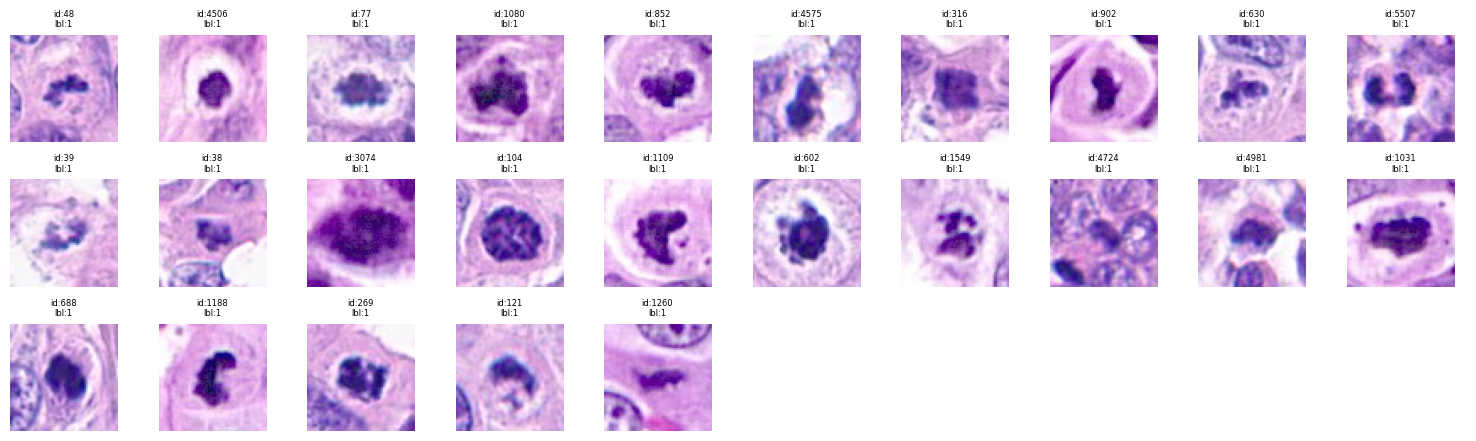

In [25]:
plotids(chosen_1)

Selected 25 points


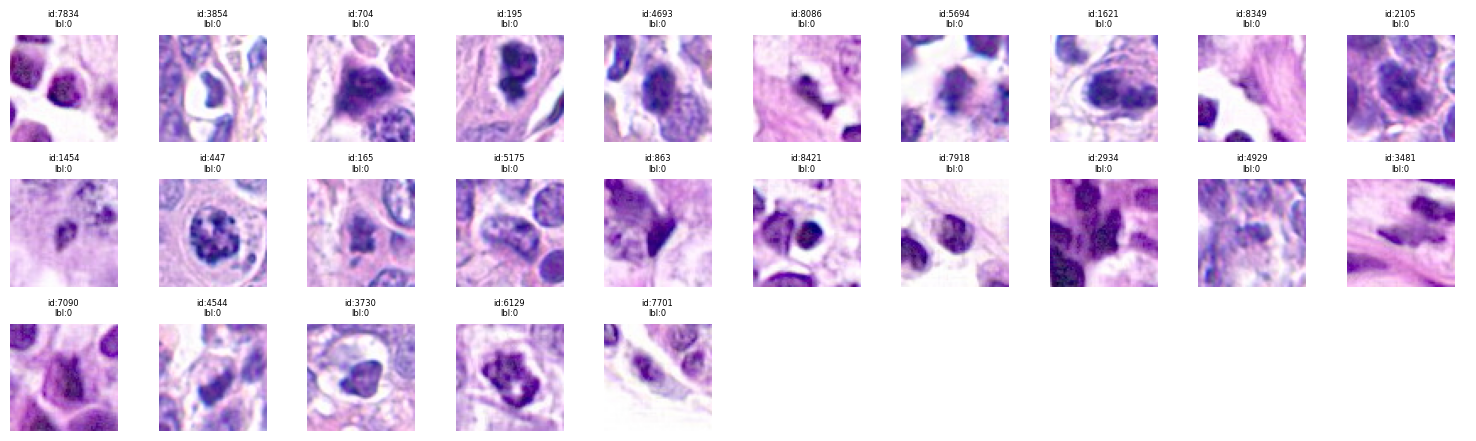

In [26]:
plotids(chosen_0)